In [ ]:
!git clone https://github.com/E-tech-coder/DataScienceCapstoneProject.git

Cloning into 'DataScienceCapstoneProject'...
remote: Enumerating objects: 290, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 290 (delta 62), reused 20 (delta 20), pack-reused 212 (from 2)
Receiving objects: 100% (290/290), 2.12 MiB | 10.32 MiB/s, done.
Resolving deltas: 100% (162/162), done.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Seniority prediction with KNN

In [ ]:
import pandas as pd

seniority = pd.read_csv("/content/DataScienceCapstoneProject/seniority.csv")
cv = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")

In [ ]:
trainCounts = seniority["label"].value_counts()
trainCounts["Professional"] = 0
testCounts = cv["seniority"].value_counts()

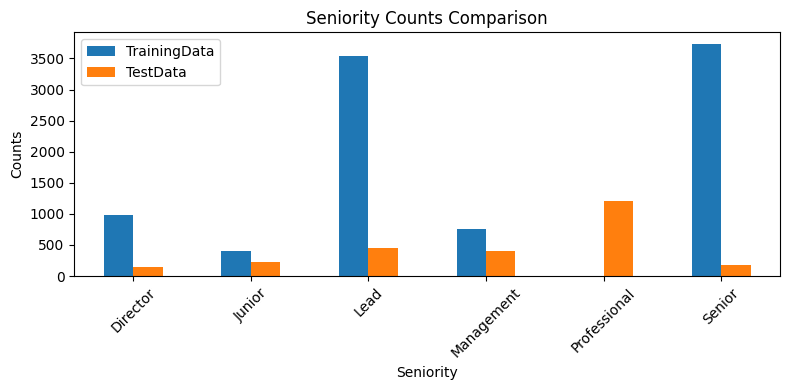

In [ ]:
import matplotlib.pyplot as plt

counts = pd.DataFrame({
    "TrainingData" : trainCounts,
    "TestData" : testCounts
})

counts.plot(kind = "bar", figsize = (8,4))
plt.xlabel("Seniority")
plt.ylabel("Counts")
plt.title("Seniority Counts Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Here we also have the similar issue of label distribution drift like we have when we predict departments.
In the training data, we have around one third of "Lead" and one third of "Senior". But in the Test data, most of the data is labeled as "Professional", which doesn't appear in the Training data.

### We split the "seniority.csv" dataset into the training data and evaluation data.

In [ ]:

import numpy as np
from sklearn.model_selection import train_test_split

X = seniority["text"]
y = seniority['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 50, test_size = 0.2, shuffle = True
)

In [ ]:
# SentenceTransformer expects a Python list of strings, not a pandas Series.
X_train = X_train.astype(str).tolist()
y_train = y_train.astype(str).tolist()
X_test = X_test.astype(str).tolist()
y_test = y_test.astype(str).tolist()

## Create Embeddings

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("TechWolf/JobBERT-v3")
X_train_embedded = model.encode(
    X_train,
    show_progress_bar = True,
    normalize_embeddings = True
)
X_test_embedded = model.encode(
    X_test,
    show_progress_bar = True,
    normalize_embeddings = True
)

Batches:   0%|          | 0/236 [00:00<?, ?it/s]

Batches:   0%|          | 0/59 [00:00<?, ?it/s]

## Train KNN classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
for k in [5, 7, 9, 11, 13, 15, 17 ,19, 21,23,25,27, 29,31]:
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine", weights = "distance")
    knn.fit(X_train_embedded, y_train)
    score = knn.score(X_test_embedded, y_test)
    print(f"K={k}, Accuracy={score:.3f}")

K=5, Accuracy=0.768
K=7, Accuracy=0.771
K=9, Accuracy=0.777
K=11, Accuracy=0.778
K=13, Accuracy=0.778
K=15, Accuracy=0.786
K=17, Accuracy=0.791
K=19, Accuracy=0.788
K=21, Accuracy=0.795
K=23, Accuracy=0.790
K=25, Accuracy=0.790
K=27, Accuracy=0.793
K=29, Accuracy=0.791
K=31, Accuracy=0.791


In [ ]:
y_pred = knn.predict(X_test_embedded)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

    Director       0.56      0.81      0.66       146
      Junior       0.46      0.78      0.58        55
        Lead       0.87      0.77      0.82       802
  Management       0.67      0.64      0.65       148
      Senior       0.84      0.84      0.84       735

    accuracy                           0.79      1886
   macro avg       0.68      0.77      0.71      1886
weighted avg       0.81      0.79      0.80      1886



###  we have the highest accuracy when k = 21, so to prevent underfitting, we test a few different k values in the following evalution process. When we train on the test dataset in the "seniority.csv" dataset, we have a 79.5% accuracy rate.

## Test on CV dataset

In [ ]:
# Embed the positions in CV dataset
X_eval_embedded = model.encode(
    cv["position"].astype(str).tolist(),
    show_progress_bar = True,
    normalize_embeddings = True
)


Batches:   0%|          | 0/82 [00:00<?, ?it/s]

In [ ]:
from sklearn.metrics import classification_report

knn = KNeighborsClassifier(n_neighbors=21, metric="cosine", weights = "distance")
knn.fit(X_train_embedded, y_train)
y_eval = cv["seniority"]
score = knn.score(X_eval_embedded, y_eval)
print(f"K=21, Accuracy={score:.3f}")

K=21, Accuracy=0.337


In [ ]:
y_pred = knn.predict(X_eval_embedded)
print(classification_report(y_pred, y_eval))

              precision    recall  f1-score   support

    Director       0.45      0.46      0.45       136
      Junior       0.41      0.43      0.42       219
        Lead       0.71      0.40      0.51       801
  Management       0.68      0.74      0.71       374
Professional       0.00      0.00      0.00         0
      Senior       0.74      0.12      0.20      1085

    accuracy                           0.34      2615
   macro avg       0.50      0.36      0.38      2615
weighted avg       0.68      0.34      0.40      2615



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


When k = 21, we have the highest accuracy rate on the linkedin CV seniority prediction, which is 33.7%

### KNN prediction on LInkedin CV Seniority without "Professional" labeled data

In [ ]:

cv = cv[cv["seniority"] != "Professional"]
X_eval_embedded = model.encode(
    cv["position"].astype(str).tolist(),
    show_progress_bar = True,
    normalize_embeddings = True
)

y_eval = cv["seniority"]
y_pred = knn.predict(X_eval_embedded)
print(classification_report(y_pred, y_eval))

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    Director       0.43      0.48      0.45       124
      Junior       0.47      0.90      0.62       121
        Lead       0.71      0.68      0.70       473
  Management       0.71      0.83      0.76       347
      Senior       0.71      0.35      0.47       339

    accuracy                           0.64      1404
   macro avg       0.60      0.65      0.60      1404
weighted avg       0.66      0.64      0.63      1404



Without the "Professional" labeled data, which is not included in the training data, the out-of-sample accuracy of our KNN model rises to 64%

# KNN-Seniority with distance threshold

In [ ]:
# Fit KNN normally
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=21,
    metric="cosine",
    weights="distance"
)
knn.fit(X_train_embedded, y_train)

# Calculate the distances with the Linkedin data

y_eval = cv["seniority"]

X_eval_embedded = model.encode(
    cv["position"].astype(str).tolist(),
    show_progress_bar = True,
    normalize_embeddings = True
)

# Evaluate with the linkedinCV data
distances, indices = knn.kneighbors(X_eval_embedded)
# distances: shape (n_samples, k)

Batches:   0%|          | 0/82 [00:00<?, ?it/s]

In [ ]:
from sklearn.metrics import accuracy_score
max_sim = 1- distances.min(axis = 1)
threshold = np.linspace(0.1,0.5,20)
# Calculate the smallest distance of our evalution sample to the nearest 21 training samples, to see if this evaluation sample is far from our training data.
# If the evaluation sample is too far from its nearest 21 training data neighbours,exceeding the threshold. We ditch it to Professional seniority.
for t in threshold :
  is_pro = max_sim < t
  y_pred = knn.predict(X_eval_embedded)
  y_pred_adj = y_pred.copy()
  y_pred_adj[is_pro] = "Professional"
  acc = accuracy_score(y_pred_adj, y_eval)
  print(f"Threshold ={t :.3f}, Accuracy={acc:.3f}")


Threshold =0.100, Accuracy=0.337
Threshold =0.121, Accuracy=0.337
Threshold =0.142, Accuracy=0.337
Threshold =0.163, Accuracy=0.337
Threshold =0.184, Accuracy=0.337
Threshold =0.205, Accuracy=0.337
Threshold =0.226, Accuracy=0.337
Threshold =0.247, Accuracy=0.337
Threshold =0.268, Accuracy=0.337
Threshold =0.289, Accuracy=0.337
Threshold =0.311, Accuracy=0.337
Threshold =0.332, Accuracy=0.337
Threshold =0.353, Accuracy=0.337
Threshold =0.374, Accuracy=0.335
Threshold =0.395, Accuracy=0.333
Threshold =0.416, Accuracy=0.331
Threshold =0.437, Accuracy=0.329
Threshold =0.458, Accuracy=0.327
Threshold =0.479, Accuracy=0.322
Threshold =0.500, Accuracy=0.317


With our distance threshold method, if the sample is too far from our training data, we dump it to the "Professional" label. It gives us a highest accuracy of 33.7%, which is the same as the accuracy before we apply this distance threshold methos. Distance threshold method doesn't help.

Possible reason :
Label ambiguity dominates the task.
LinkedIn titles like:
“Associate”
“Consultant”
“Staff”
“Member”
“Analyst”
are:
semantically very close,
but map to different seniority labels
So:
high cosine similarity ≠ clear label